# BANKRUPT PREDICTION

## Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## 1. Load Dataset

In [2]:
data = pd.read_csv('bankruptcy_dataset_50k.csv')
data

,Company_ID,Industry,Years_in_Operation,Annual_Revenue,Net_Profit,Total_Assets,Total_Liabilities,Debt_to_Equity_Ratio,Current_Ratio,Cash_Flow,Credit_Rating,Employee_Count,Market_Trend,Bankrupt
0,F22781,Manufacturing,12,2445519,-469932.0,2216219,9060819,4.31,0.86,NaN,C,712,Growing,1
1,F47587,Retail,3,5384082,309092.0,450974,2027926,1.86,2.49,-847235.0,B,289,Growing,0
2,F21947,IT,17,755016,582196.0,1402931,1672345,0.64,2.50,-323779.0,B,27,Declining,0
3,F30357,IT,34,404949,1196471.0,7216061,1430564,0.33,NaN,942794.0,A,792,Declining,0
4,F15335,Retail,34,1116251,6370.0,1886861,2245431,4.26,2.07,-189820.0,C,891,Growing,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,F11965,Finance,2,2028621,1129754.0,3061974,719753,3.80,1.53,-946831.0,B,88,Growing,0
49996,F11514,Retail,38,9336536,128475.0,8673125,306844,4.30,2.85,500197.0,A,570,Declining,0
49997,F46567,IT,1,358172,NaN,3565165,3620734,1.35,2.93,97802.0,B,282,Growing,0
49998,F17445,IT,39,488124,407092.0,5575343,1361116,3.49,2.02,-753400.0,C,125,Declining,1


## 2. Understanding the Data

In [3]:
data.head()

,Company_ID,Industry,Years_in_Operation,Annual_Revenue,Net_Profit,Total_Assets,Total_Liabilities,Debt_to_Equity_Ratio,Current_Ratio,Cash_Flow,Credit_Rating,Employee_Count,Market_Trend,Bankrupt
0,F22781,Manufacturing,12,2445519,-469932.0,2216219,9060819,4.31,0.86,NaN,C,712,Growing,1
1,F47587,Retail,3,5384082,309092.0,450974,2027926,1.86,2.49,-847235.0,B,289,Growing,0
2,F21947,IT,17,755016,582196.0,1402931,1672345,0.64,2.50,-323779.0,B,27,Declining,0
3,F30357,IT,34,404949,1196471.0,7216061,1430564,0.33,NaN,942794.0,A,792,Declining,0
4,F15335,Retail,34,1116251,6370.0,1886861,2245431,4.26,2.07,-189820.0,C,891,Growing,1


In [4]:
data.tail()

,Company_ID,Industry,Years_in_Operation,Annual_Revenue,Net_Profit,Total_Assets,Total_Liabilities,Debt_to_Equity_Ratio,Current_Ratio,Cash_Flow,Credit_Rating,Employee_Count,Market_Trend,Bankrupt
49995,F11965,Finance,2,2028621,1129754.0,3061974,719753,3.80,1.53,-946831.0,B,88,Growing,0
49996,F11514,Retail,38,9336536,128475.0,8673125,306844,4.30,2.85,500197.0,A,570,Declining,0
49997,F46567,IT,1,358172,NaN,3565165,3620734,1.35,2.93,97802.0,B,282,Growing,0
49998,F17445,IT,39,488124,407092.0,5575343,1361116,3.49,2.02,-753400.0,C,125,Declining,1
49999,F20517,Finance,33,1271659,516944.0,6817215,316708,1.14,1.44,12317.0,B,635,Stable,0


In [5]:
data.shape

(50000, 14)

In [6]:
data.size

700000

In [7]:
data.columns

Index(['Company_ID', 'Industry', 'Years_in_Operation', 'Annual_Revenue',
       'Net_Profit', 'Total_Assets', 'Total_Liabilities',
       'Debt_to_Equity_Ratio', 'Current_Ratio', 'Cash_Flow', 'Credit_Rating',
       'Employee_Count', 'Market_Trend', 'Bankrupt'],
      dtype='object')

In [8]:
data.describe()

,Years_in_Operation,Annual_Revenue,Net_Profit,Total_Assets,Total_Liabilities,Debt_to_Equity_Ratio,Current_Ratio,Cash_Flow,Employee_Count,Bankrupt
count,50000.000000,5.000000e+04,4.750000e+04,5.000000e+04,5.000000e+04,50000.000000,47500.000000,4.750000e+04,50000.000000,50000.000000
mean,20.095500,2.141385e+06,2.000481e+05,6.729198e+06,4.615209e+06,2.637895,1.753977,9.796271e+04,505.269440,0.413220
std,11.268783,3.545484e+06,4.998657e+05,1.191202e+07,1.081290e+07,1.865571,0.722900,4.023078e+05,285.170107,0.492417
min,1.000000,1.992400e+04,-1.679456e+06,2.863500e+04,1.105700e+04,0.100000,0.500000,-1.599694e+06,10.000000,0.000000
25%,10.000000,6.180755e+05,-1.373130e+05,1.453431e+06,8.314598e+05,1.320000,1.120000,-1.747610e+05,259.000000,0.000000
50%,20.000000,1.212648e+06,1.996370e+05,3.295804e+06,1.982492e+06,2.560000,1.760000,9.768650e+04,507.000000,0.000000
75%,30.000000,2.419634e+06,5.355712e+05,7.331511e+06,4.773278e+06,3.790000,2.380000,3.706625e+05,752.000000,1.000000
max,39.000000,1.555429e+08,2.238926e+06,4.350137e+08,7.682743e+08,24.950000,3.000000,1.893778e+06,999.000000,1.000000


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Company_ID            50000 non-null  object 
 1   Industry              50000 non-null  object 
 2   Years_in_Operation    50000 non-null  int64  
 3   Annual_Revenue        50000 non-null  int64  
 4   Net_Profit            47500 non-null  float64
 5   Total_Assets          50000 non-null  int64  
 6   Total_Liabilities     50000 non-null  int64  
 7   Debt_to_Equity_Ratio  50000 non-null  float64
 8   Current_Ratio         47500 non-null  float64
 9   Cash_Flow             47500 non-null  float64
 10  Credit_Rating         50000 non-null  object 
 11  Employee_Count        50000 non-null  int64  
 12  Market_Trend          50000 non-null  object 
 13  Bankrupt              50000 non-null  int64  
dtypes: float64(4), int64(6), object(4)
memory usage: 5.3+ MB


In [10]:
data.isna().sum()

Company_ID                 0
Industry                   0
Years_in_Operation         0
Annual_Revenue             0
Net_Profit              2500
Total_Assets               0
Total_Liabilities          0
Debt_to_Equity_Ratio       0
Current_Ratio           2500
Cash_Flow               2500
Credit_Rating              0
Employee_Count             0
Market_Trend               0
Bankrupt                   0
dtype: int64

In [11]:
data.corr(numeric_only=True)

,Years_in_Operation,Annual_Revenue,Net_Profit,Total_Assets,Total_Liabilities,Debt_to_Equity_Ratio,Current_Ratio,Cash_Flow,Employee_Count,Bankrupt
Years_in_Operation,1.000000,-0.003963,0.006617,0.002970,-0.000374,-0.003416,-0.002309,-0.004530,0.000197,-0.001658
Annual_Revenue,-0.003963,1.000000,0.000745,-0.000389,0.002005,0.244426,-0.006353,0.011190,0.001442,0.023541
Net_Profit,0.006617,0.000745,1.000000,-0.003240,0.000301,0.002912,0.000880,0.004162,-0.007165,-0.330805
Total_Assets,0.002970,-0.000389,-0.003240,1.000000,0.000103,0.000344,0.004288,-0.002406,-0.003227,0.003174
Total_Liabilities,-0.000374,0.002005,0.000301,0.000103,1.000000,0.007007,0.004414,0.001124,-0.004677,-0.002175
Debt_to_Equity_Ratio,-0.003416,0.244426,0.002912,0.000344,0.007007,1.000000,-0.001223,0.007126,-0.001499,0.304583
Current_Ratio,-0.002309,-0.006353,0.000880,0.004288,0.004414,-0.001223,1.000000,-0.002653,0.000761,-0.236027
Cash_Flow,-0.004530,0.011190,0.004162,-0.002406,0.001124,0.007126,-0.002653,1.000000,-0.005792,-0.102318
Employee_Count,0.000197,0.001442,-0.007165,-0.003227,-0.004677,-0.001499,0.000761,-0.005792,1.000000,0.003780
Bankrupt,-0.001658,0.023541,-0.330805,0.003174,-0.002175,0.304583,-0.236027,-0.102318,0.003780,1.000000


In [12]:
data['Years_in_Operation'].unique()

array([12,  3, 17, 34, 36, 37, 21,  5, 13, 14, 19, 30,  2, 10,  4,  1, 26,
       31, 16, 22, 32, 18, 24,  6, 23, 28, 15, 25, 29, 20, 35, 39,  8, 33,
       11,  7, 27,  9, 38])

In [13]:
data['Annual_Revenue'].unique()

array([2445519, 5384082,  755016, ...,  358172,  488124, 1271659],
      shape=(49636,))

In [14]:
data['Net_Profit'].unique()

array([-469932.,  309092.,  582196., ...,  128475.,  407092.,  516944.],
      shape=(46830,))

In [15]:
data['Total_Assets'].unique()

array([2216219,  450974, 1402931, ..., 3565165, 5575343, 6817215],
      shape=(49852,))

In [16]:
data['Total_Liabilities'].unique()

array([9060819, 2027926, 1672345, ..., 3620734, 1361116,  316708],
      shape=(49775,))

In [17]:
data['Cash_Flow'].unique()

array([     nan, -847235., -323779., ...,   97802., -753400.,   12317.],
      shape=(46774,))

In [18]:
data['Bankrupt'].unique()

array([1, 0])

In [19]:
data['Years_in_Operation'].value_counts()

Years_in_Operation
30    1348
38    1334
36    1333
2     1326
21    1321
29    1320
32    1317
5     1312
22    1310
33    1308
23    1301
26    1299
10    1297
25    1290
12    1285
3     1284
27    1283
17    1282
19    1280
1     1278
39    1277
9     1276
34    1276
20    1276
28    1274
37    1272
24    1272
16    1270
18    1267
31    1266
7     1261
11    1257
15    1255
35    1247
4     1246
8     1243
13    1229
6     1222
14    1206
Name: count, dtype: int64

In [20]:
data['Annual_Revenue'].value_counts()

Annual_Revenue
535077     3
289395     2
937304     2
510949     2
630316     2
          ..
3335628    1
721216     1
2721880    1
355496     1
1271659    1
Name: count, Length: 49636, dtype: int64

In [21]:
data['Net_Profit'].value_counts()

Net_Profit
-246437.0     3
 438541.0     3
 255098.0     2
 344193.0     2
 454296.0     2
             ..
 1127211.0    1
 273951.0     1
-486783.0     1
 694679.0     1
 516944.0     1
Name: count, Length: 46829, dtype: int64

In [22]:
data['Total_Assets'].value_counts()

Total_Assets
1442784     3
552452      2
1835016     2
421676      2
3572421     2
           ..
3035640     1
4292666     1
10038233    1
3138511     1
6817215     1
Name: count, Length: 49852, dtype: int64

In [23]:
data['Total_Liabilities'].value_counts()

Total_Liabilities
457230     3
225382     3
945121     2
616462     2
792597     2
          ..
9638845    1
438708     1
3385414    1
1466736    1
316708     1
Name: count, Length: 49775, dtype: int64

In [24]:
data['Cash_Flow'].value_counts()

Cash_Flow
 234319.0    3
-17690.0     3
 298402.0    3
 13607.0     3
-145832.0    3
            ..
 234980.0    1
 103801.0    1
 79169.0     1
 292709.0    1
 12317.0     1
Name: count, Length: 46773, dtype: int64

In [25]:
data['Bankrupt'].value_counts()

Bankrupt
0    29339
1    20661
Name: count, dtype: int64

## 3. Exploratory Data Analysis (EDA)

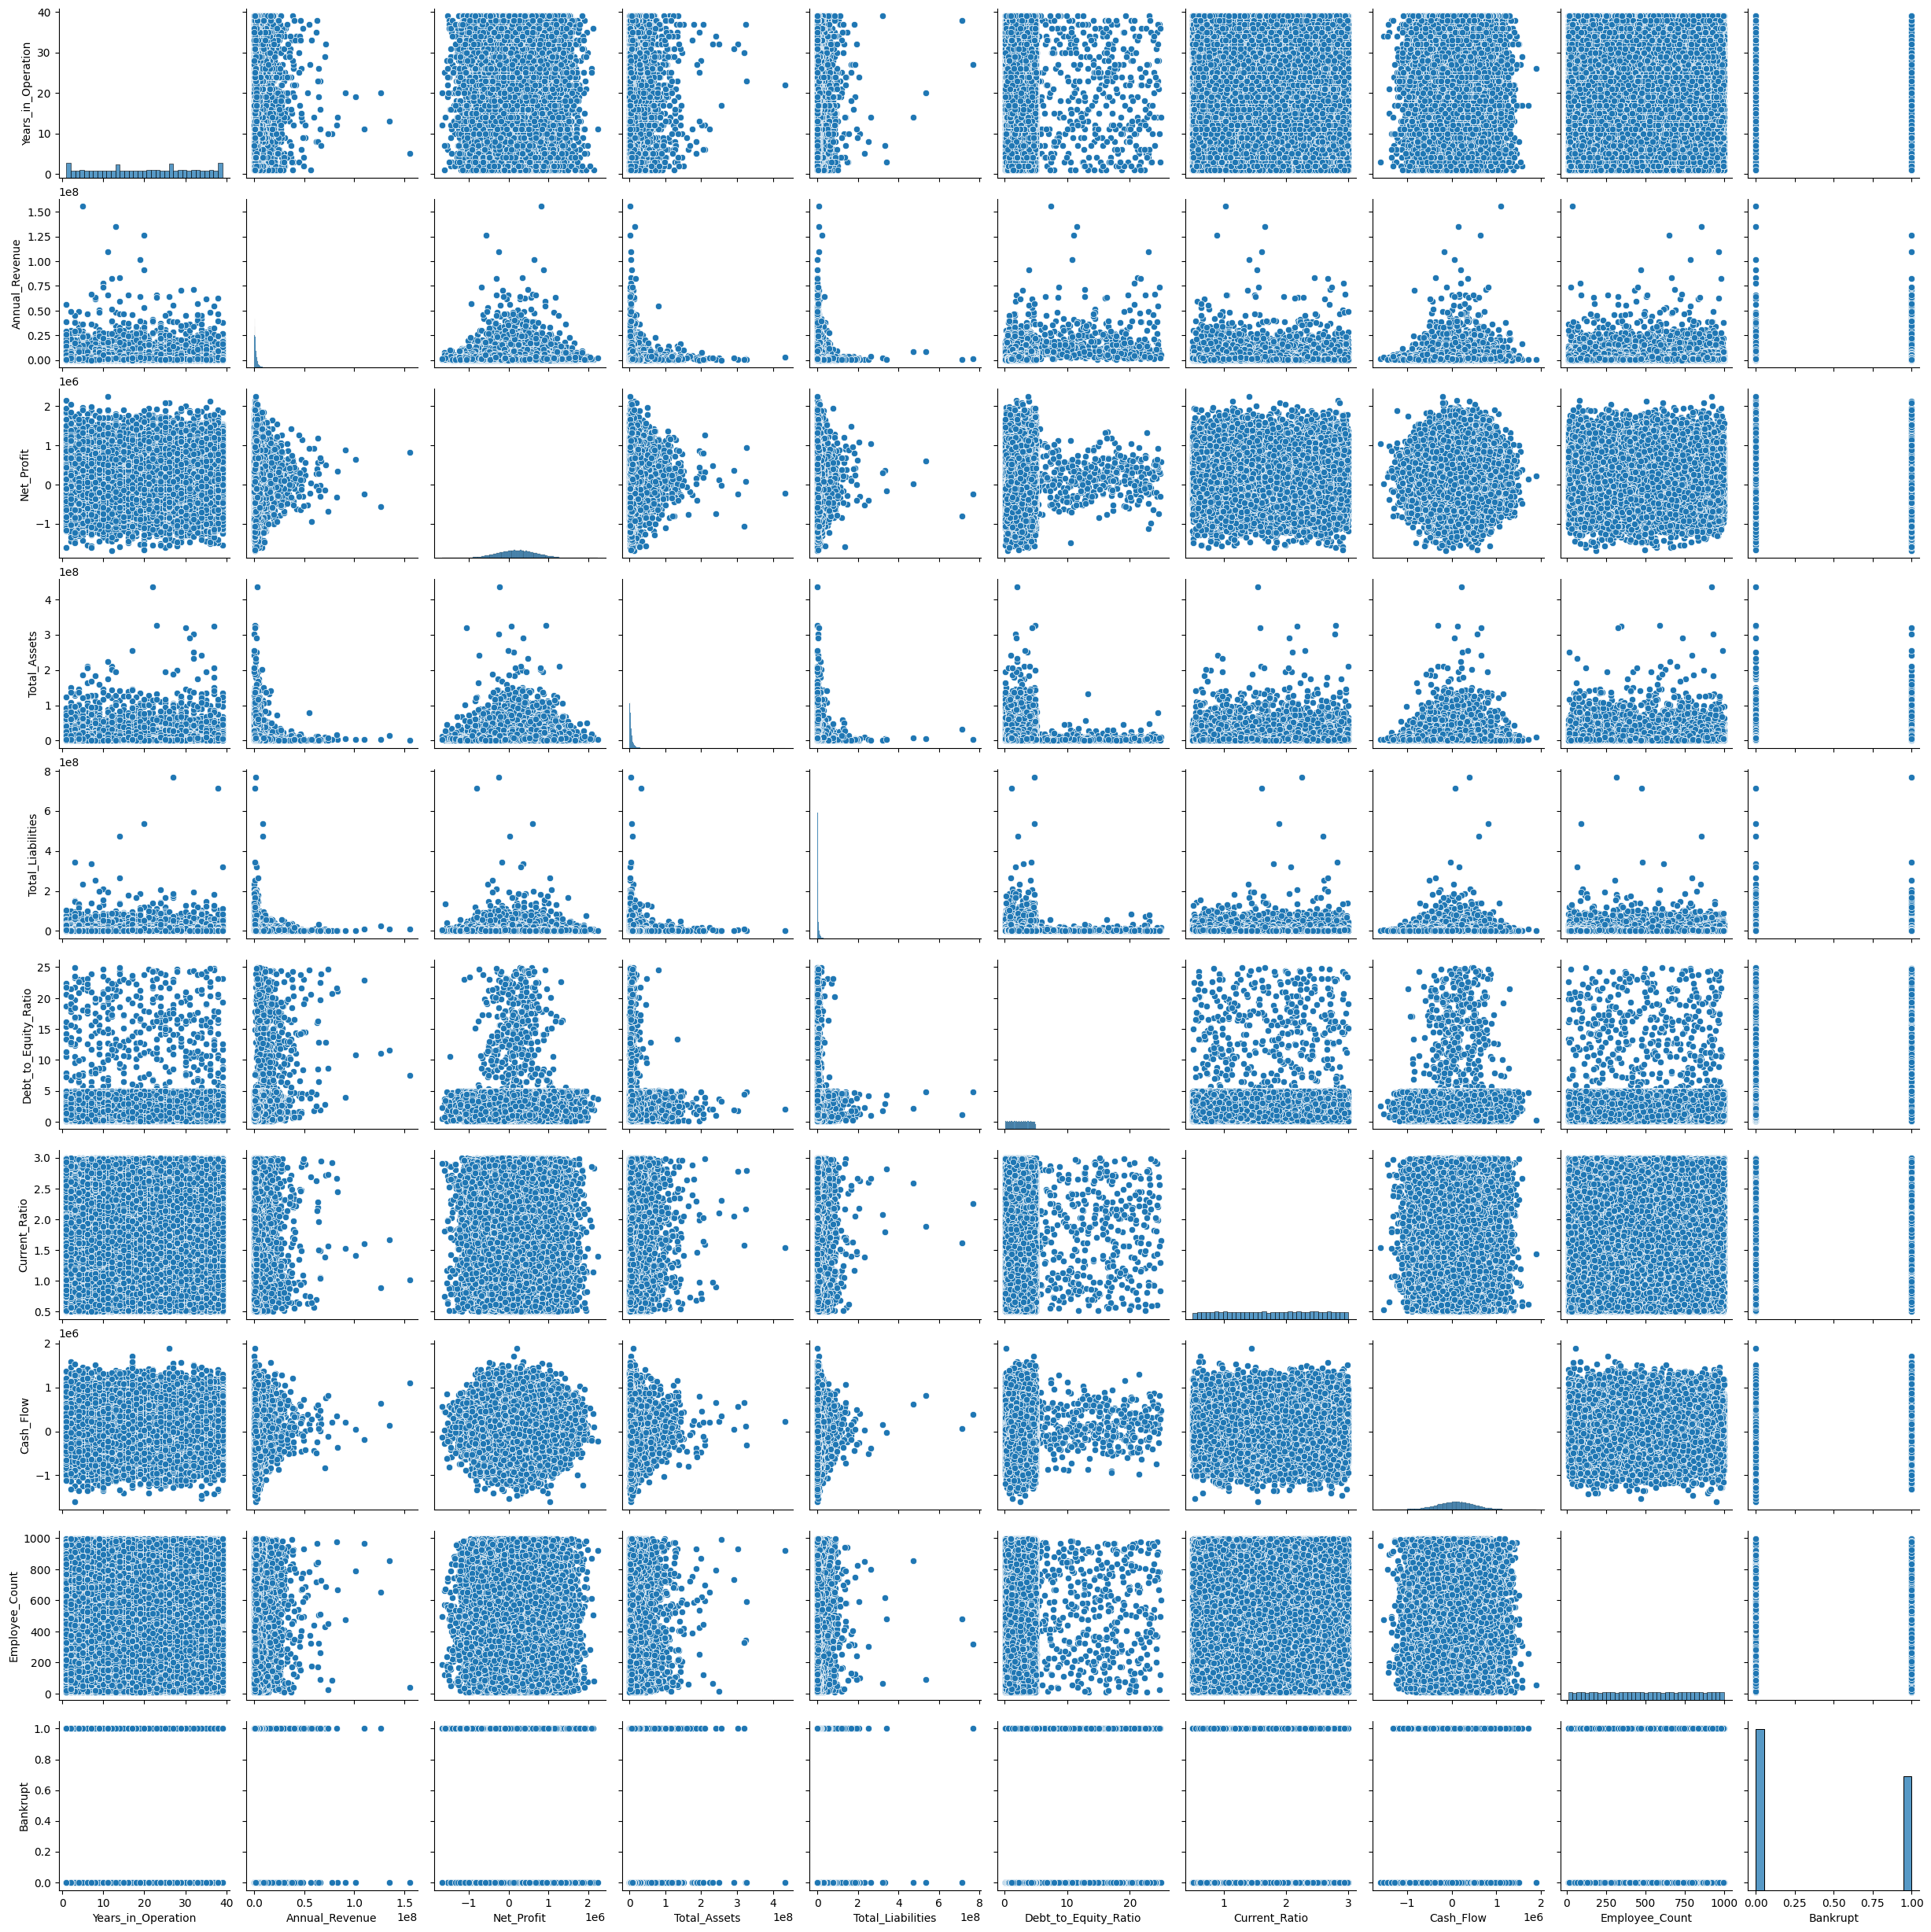

In [26]:
sns.pairplot(data)
plt.show()

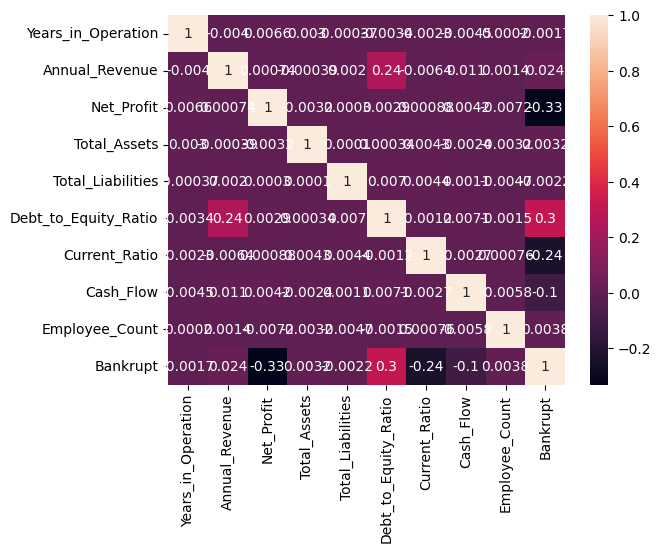

In [27]:
d = data.select_dtypes('number').corr()
sns.heatmap(d, annot=True)
plt.show()

Industry


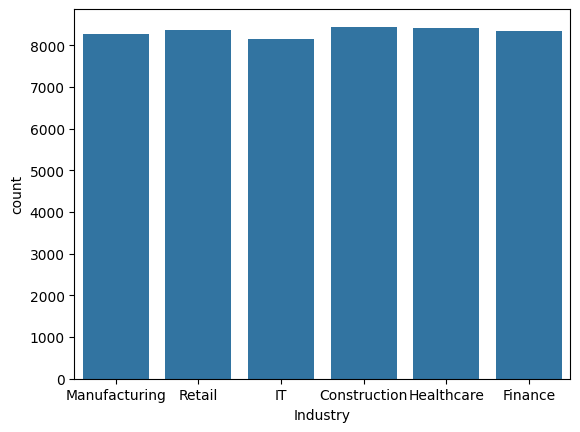

Credit_Rating


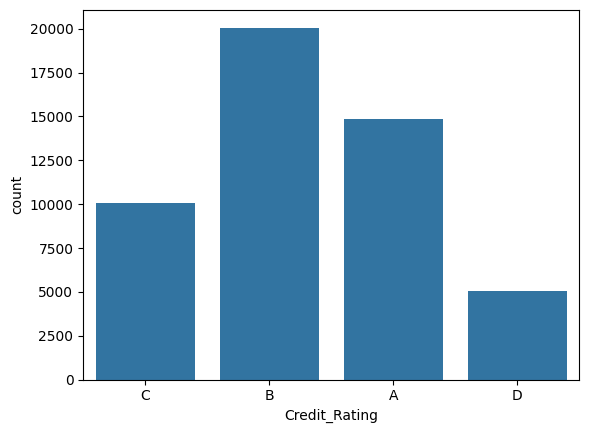

Market_Trend


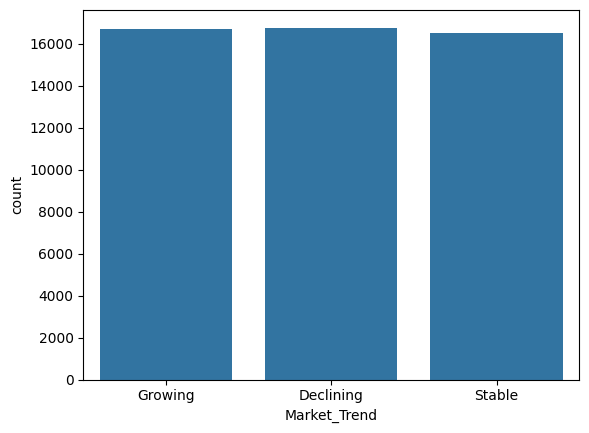

In [28]:
a = ['Industry', 'Credit_Rating', 'Market_Trend']
for i in a:
    print(i)
    sns.countplot(x=data[i])
    plt.show()

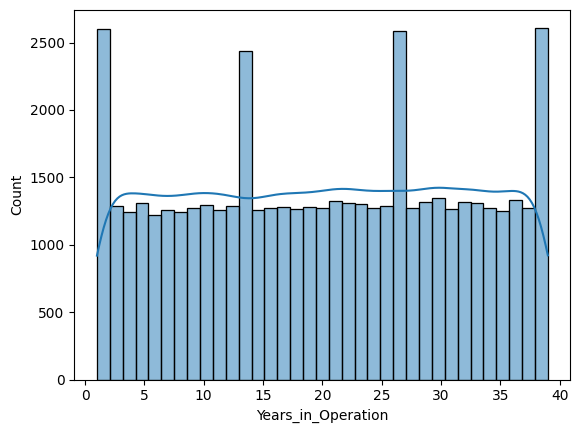

In [29]:
sns.histplot(data['Years_in_Operation'], kde=True)
plt.show()

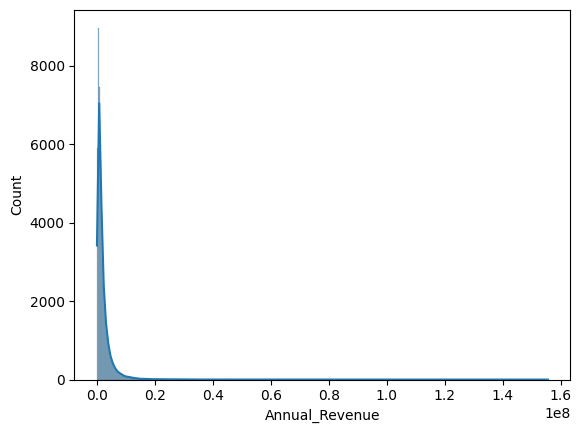

In [30]:
sns.histplot(data['Annual_Revenue'], kde=True)
plt.show()

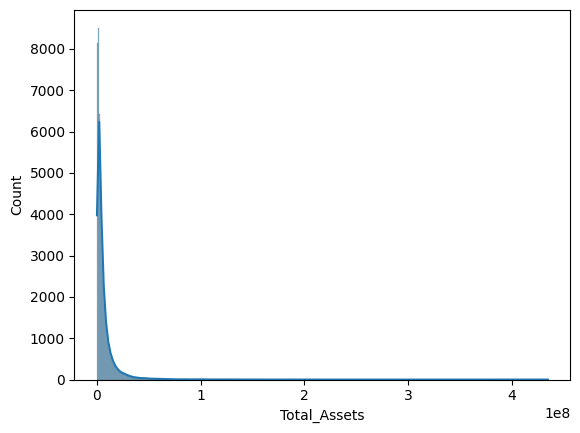

In [31]:
sns.histplot(data['Total_Assets'], kde=True)
plt.show()

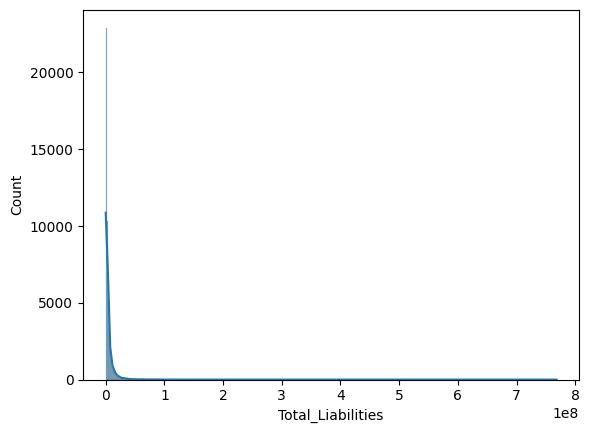

In [32]:
sns.histplot(data['Total_Liabilities'], kde=True)
plt.show()

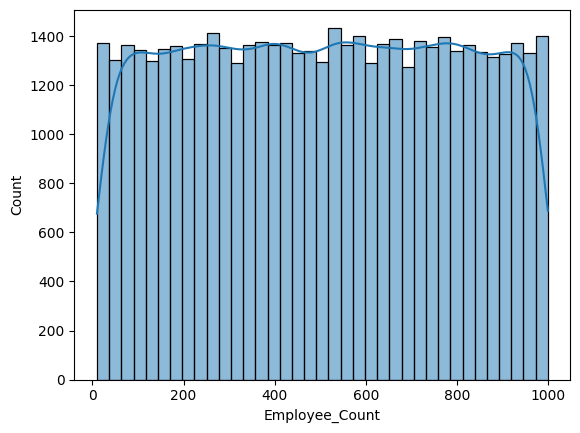

In [33]:
sns.histplot(data['Employee_Count'], kde=True)
plt.show()

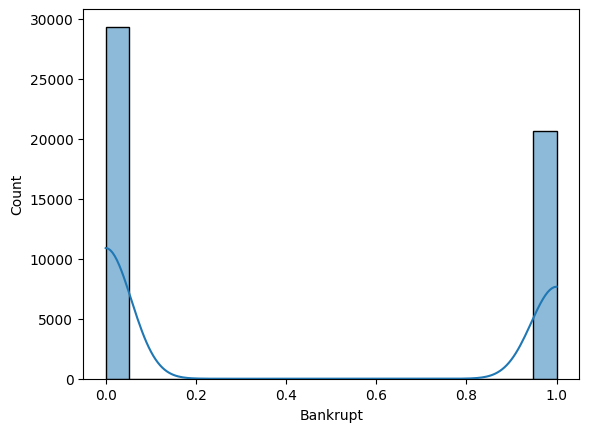

In [34]:
sns.histplot(data['Bankrupt'], kde=True)
plt.show()

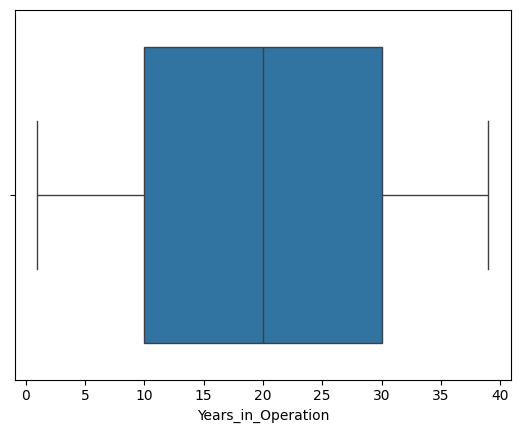

In [35]:
sns.boxplot(x='Years_in_Operation', data=data)
plt.show()

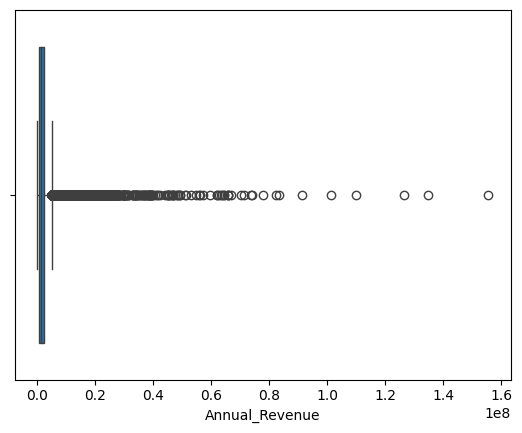

In [36]:
sns.boxplot(x='Annual_Revenue', data=data)
plt.show()

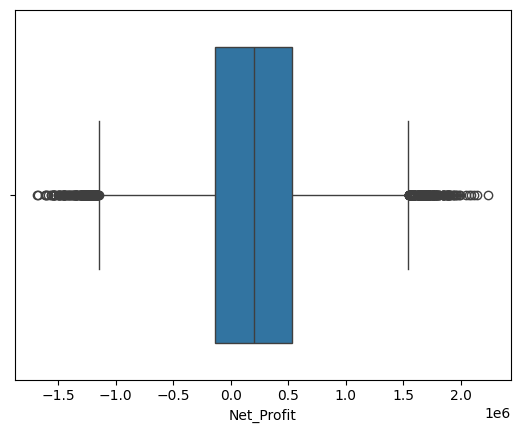

In [37]:
sns.boxplot(x='Net_Profit', data=data)
plt.show()

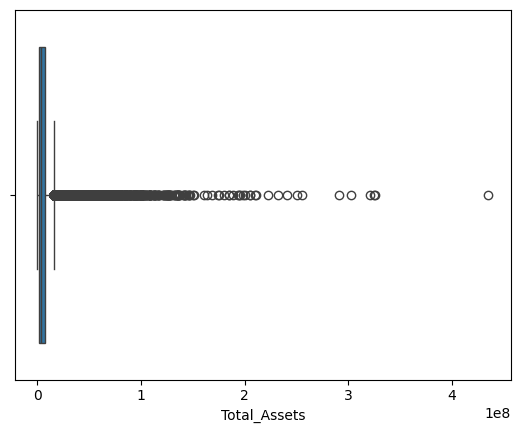

In [38]:
sns.boxplot(x='Total_Assets', data=data)
plt.show()

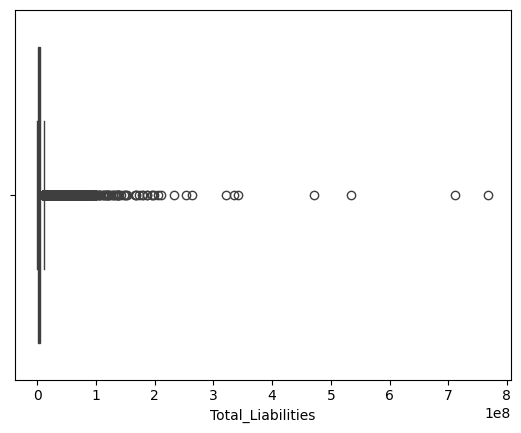

In [39]:
sns.boxplot(x='Total_Liabilities', data=data)
plt.show()

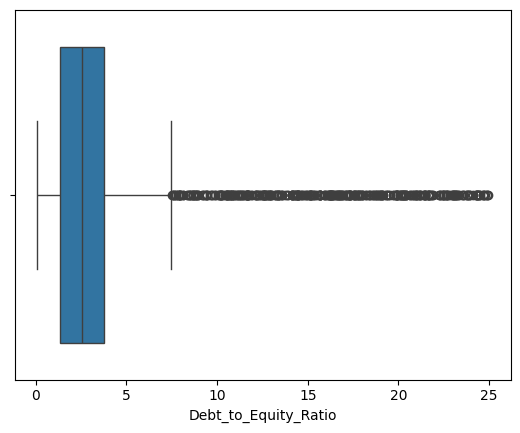

In [40]:
sns.boxplot(x='Debt_to_Equity_Ratio', data=data)
plt.show()

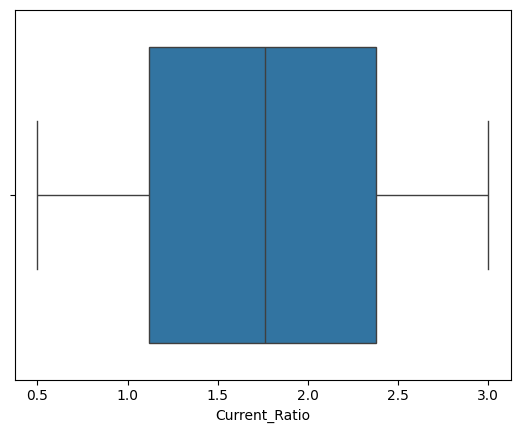

In [41]:
sns.boxplot(x='Current_Ratio', data=data)
plt.show()

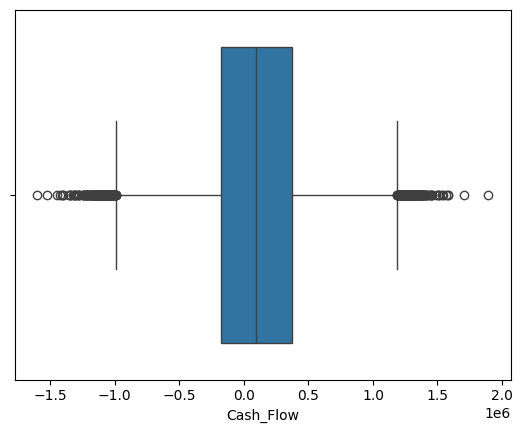

In [42]:
sns.boxplot(x='Cash_Flow', data=data)
plt.show()

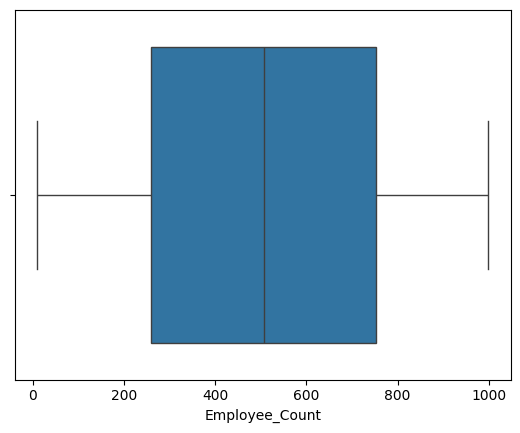

In [43]:
sns.boxplot(x='Employee_Count', data=data)
plt.show()

## 4. Preprocessing

In [44]:
data.duplicated().sum()

np.int64(0)

In [45]:
# Fill missing values
data = data.copy()
data['Net_Profit']    = data['Net_Profit'].fillna(data['Net_Profit'].mode()[0])
data['Current_Ratio'] = data['Current_Ratio'].fillna(data['Current_Ratio'].mode()[0])
data['Cash_Flow']     = data['Cash_Flow'].fillna(data['Cash_Flow'].mode()[0])
data.isna().sum()

Company_ID              0
Industry                0
Years_in_Operation      0
Annual_Revenue          0
Net_Profit              0
Total_Assets            0
Total_Liabilities       0
Debt_to_Equity_Ratio    0
Current_Ratio           0
Cash_Flow               0
Credit_Rating           0
Employee_Count          0
Market_Trend            0
Bankrupt                0
dtype: int64

In [46]:
from sklearn.preprocessing import LabelEncoder

In [47]:
# Label Encoding
le = LabelEncoder()
data['Company_ID'] = le.fit_transform(data['Company_ID'])

le1 = LabelEncoder()
data['Industry'] = le1.fit_transform(data['Industry'])

le2 = LabelEncoder()
data['Credit_Rating'] = le2.fit_transform(data['Credit_Rating'])

le3 = LabelEncoder()
data['Market_Trend'] = le3.fit_transform(data['Market_Trend'])

data

,Company_ID,Industry,Years_in_Operation,Annual_Revenue,Net_Profit,Total_Assets,Total_Liabilities,Debt_to_Equity_Ratio,Current_Ratio,Cash_Flow,Credit_Rating,Employee_Count,Market_Trend,Bankrupt
0,22780,4,12,2445519,-469932.0,2216219,9060819,4.31,0.86,-145832.0,2,712,1,1
1,47586,5,3,5384082,309092.0,450974,2027926,1.86,2.49,-847235.0,1,289,1,0
2,21946,3,17,755016,582196.0,1402931,1672345,0.64,2.50,-323779.0,1,27,0,0
3,30356,3,34,404949,1196471.0,7216061,1430564,0.33,2.94,942794.0,0,792,0,0
4,15334,5,34,1116251,6370.0,1886861,2245431,4.26,2.07,-189820.0,2,891,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,11964,1,2,2028621,1129754.0,3061974,719753,3.80,1.53,-946831.0,1,88,1,0
49996,11513,5,38,9336536,128475.0,8673125,306844,4.30,2.85,500197.0,0,570,0,0
49997,46566,3,1,358172,-246437.0,3565165,3620734,1.35,2.93,97802.0,1,282,1,0
49998,17444,3,39,488124,407092.0,5575343,1361116,3.49,2.02,-753400.0,2,125,0,1


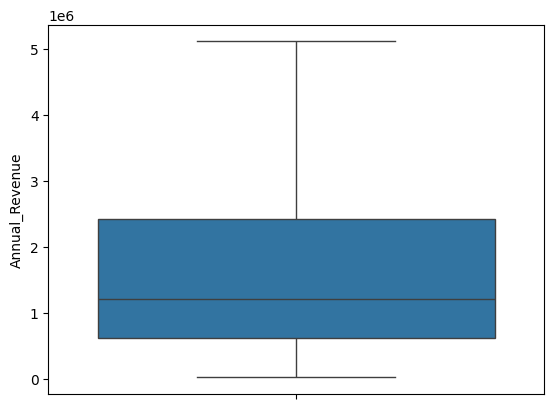

In [48]:
# Outlier Handling with IQR — Annual_Revenue
Q1 = data['Annual_Revenue'].quantile(0.25)
Q3 = data['Annual_Revenue'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR
new_data = data.copy()
new_data.loc[new_data['Annual_Revenue'] > upper_limit, 'Annual_Revenue'] = upper_limit
new_data.loc[new_data['Annual_Revenue'] < lower_limit, 'Annual_Revenue'] = lower_limit
sns.boxplot(new_data['Annual_Revenue'])
plt.show()

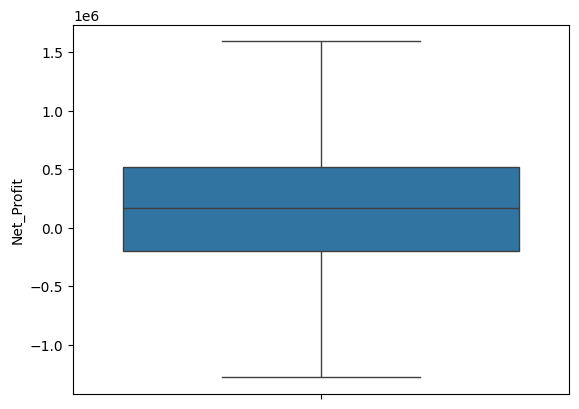

In [49]:
# Net_Profit
Q1 = data['Net_Profit'].quantile(0.25)
Q3 = data['Net_Profit'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR
new_data.loc[new_data['Net_Profit'] > upper_limit, 'Net_Profit'] = upper_limit
new_data.loc[new_data['Net_Profit'] < lower_limit, 'Net_Profit'] = lower_limit
sns.boxplot(new_data['Net_Profit'])
plt.show()

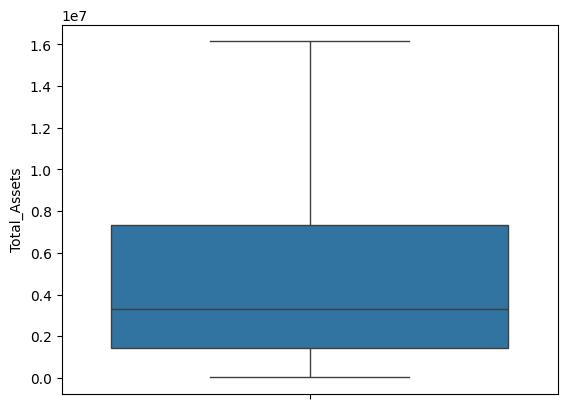

In [50]:
# Total_Assets
Q1 = data['Total_Assets'].quantile(0.25)
Q3 = data['Total_Assets'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR
new_data.loc[new_data['Total_Assets'] > upper_limit, 'Total_Assets'] = upper_limit
new_data.loc[new_data['Total_Assets'] < lower_limit, 'Total_Assets'] = lower_limit
sns.boxplot(new_data['Total_Assets'])
plt.show()

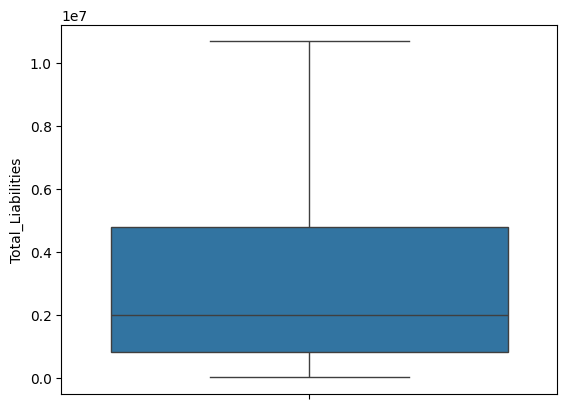

In [51]:
# Total_Liabilities
Q1 = data['Total_Liabilities'].quantile(0.25)
Q3 = data['Total_Liabilities'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR
new_data.loc[new_data['Total_Liabilities'] > upper_limit, 'Total_Liabilities'] = upper_limit
new_data.loc[new_data['Total_Liabilities'] < lower_limit, 'Total_Liabilities'] = lower_limit
sns.boxplot(new_data['Total_Liabilities'])
plt.show()

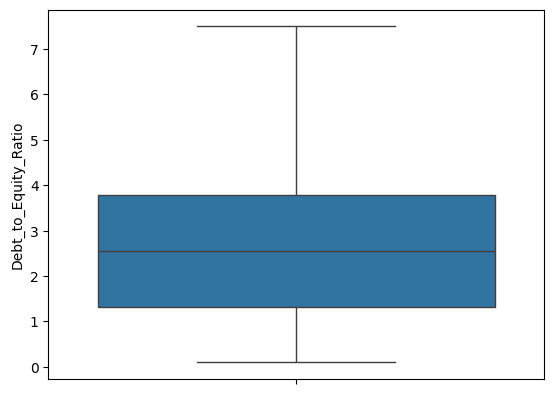

In [52]:
# Debt_to_Equity_Ratio
Q1 = data['Debt_to_Equity_Ratio'].quantile(0.25)
Q3 = data['Debt_to_Equity_Ratio'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR
new_data.loc[new_data['Debt_to_Equity_Ratio'] > upper_limit, 'Debt_to_Equity_Ratio'] = upper_limit
new_data.loc[new_data['Debt_to_Equity_Ratio'] < lower_limit, 'Debt_to_Equity_Ratio'] = lower_limit
sns.boxplot(new_data['Debt_to_Equity_Ratio'])
plt.show()

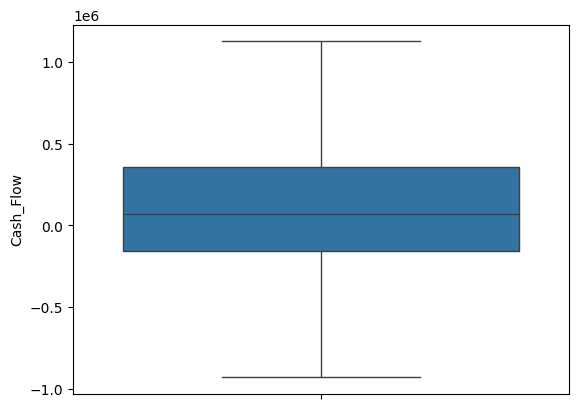

In [53]:
# Cash_Flow
Q1 = data['Cash_Flow'].quantile(0.25)
Q3 = data['Cash_Flow'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR
new_data.loc[new_data['Cash_Flow'] > upper_limit, 'Cash_Flow'] = upper_limit
new_data.loc[new_data['Cash_Flow'] < lower_limit, 'Cash_Flow'] = lower_limit
sns.boxplot(new_data['Cash_Flow'])
plt.show()

In [54]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Company_ID            50000 non-null  int64  
 1   Industry              50000 non-null  int64  
 2   Years_in_Operation    50000 non-null  int64  
 3   Annual_Revenue        50000 non-null  int64  
 4   Net_Profit            50000 non-null  float64
 5   Total_Assets          50000 non-null  int64  
 6   Total_Liabilities     50000 non-null  int64  
 7   Debt_to_Equity_Ratio  50000 non-null  float64
 8   Current_Ratio         50000 non-null  float64
 9   Cash_Flow             50000 non-null  float64
 10  Credit_Rating         50000 non-null  int64  
 11  Employee_Count        50000 non-null  int64  
 12  Market_Trend          50000 non-null  int64  
 13  Bankrupt              50000 non-null  int64  
dtypes: float64(4), int64(10)
memory usage: 5.3 MB


# DATA SPLITTING

In [55]:
x = new_data.drop('Bankrupt', axis=1)
y = new_data['Bankrupt']
x

,Company_ID,Industry,Years_in_Operation,Annual_Revenue,Net_Profit,Total_Assets,Total_Liabilities,Debt_to_Equity_Ratio,Current_Ratio,Cash_Flow,Credit_Rating,Employee_Count,Market_Trend
0,22780,4,12,2445519.0,-469932.0,2216219,9060819.0,4.31,0.86,-145832.000,2,712,1
1,47586,5,3,5121970.5,309092.0,450974,2027926.0,1.86,2.49,-847235.000,1,289,1
2,21946,3,17,755016.0,582196.0,1402931,1672345.0,0.64,2.50,-323779.000,1,27,0
3,30356,3,34,404949.0,1196471.0,7216061,1430564.0,0.33,2.94,942794.000,0,792,0
4,15334,5,34,1116251.0,6370.0,1886861,2245431.0,4.26,2.07,-189820.000,2,891,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,11964,1,2,2028621.0,1129754.0,3061974,719753.0,3.80,1.53,-927841.375,1,88,1
49996,11513,5,38,5121970.5,128475.0,8673125,306844.0,4.30,2.85,500197.000,0,570,0
49997,46566,3,1,358172.0,-246437.0,3565165,3620734.0,1.35,2.93,97802.000,1,282,1
49998,17444,3,39,488124.0,407092.0,5575343,1361116.0,3.49,2.02,-753400.000,2,125,0


# TRAIN TEST SPLIT

In [56]:
from sklearn.model_selection import train_test_split

In [57]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

# SCALING

In [58]:
from sklearn.preprocessing  import  StandardScaler

In [59]:
sd = StandardScaler()
x_train = sd.fit_transform(x_train)
x_test  = sd.transform(x_test)
x_train

array([[ 0.22454565,  0.30064155, -1.51434085, ..., -1.17310266,
        -1.22638678,  0.00888571],
       [-0.15218108, -0.28384183,  0.08291802, ...,  2.00349574,
         0.95875797,  1.23329417],
       [ 0.31416987,  0.88512493,  0.17165462, ..., -1.17310266,
         1.7116524 ,  1.23329417],
       ...,
       [ 0.12015734, -0.86832521,  0.61533764, ...,  0.94462961,
        -1.25440145,  1.23329417],
       [-0.16431119, -1.45280859, -0.62697481, ...,  0.94462961,
        -0.07078138,  1.23329417],
       [ 0.21816868,  0.88512493,  0.79281085, ...,  0.94462961,
        -1.15635009, -1.21552276]], shape=(35000, 13))

In [60]:
x_train_DF = pd.DataFrame(x_train)
x_train_DF

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.224546,0.300642,-1.514341,-0.916604,-0.854440,-0.699671,0.792730,0.534289,0.332027,-0.389920,-1.173103,-1.226387,0.008886
1,-0.152181,-0.283842,0.082918,-0.273193,0.512338,-0.163093,-0.041649,1.455281,0.251948,-0.481402,2.003496,0.958758,1.233294
2,0.314170,0.885125,0.171655,-0.939380,0.232837,0.434748,-0.667399,1.509457,1.479831,0.318399,-1.173103,1.711652,1.233294
3,0.193562,-0.868325,-1.691814,2.288497,0.187636,-0.959137,-0.929589,-1.219660,-1.509798,1.506266,-0.114237,-0.757141,-1.215523
4,-1.267251,-1.452809,1.413967,-1.021595,-1.777608,-0.197989,-0.251162,-1.057132,1.172861,-0.195997,-1.173103,1.200385,1.233294
...,...,...,...,...,...,...,...,...,...,...,...,...,...
34995,-0.233695,-0.283842,1.147757,0.360456,0.561447,0.977383,-0.895260,-1.510856,-0.108409,1.342861,-0.114237,-0.869200,-1.215523
34996,0.084945,1.469608,0.526601,0.111636,-0.573994,-0.596921,-0.518453,-0.556004,0.812503,1.770180,0.944630,0.100809,-1.215523
34997,0.120157,-0.868325,0.615338,-0.584081,1.912489,-0.513019,-0.368674,-1.124852,-1.483105,1.237440,0.944630,-1.254401,1.233294
34998,-0.164311,-1.452809,-0.626975,-0.933735,-0.854440,-0.095546,-0.973097,0.425937,1.106128,1.998972,0.944630,-0.070781,1.233294


In [61]:
pip install --upgrade scikit-learn imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


## MODEL BUILDING- (INITIAL)

# K- NEAREST NEIGHBORS (KNN)

In [62]:
from sklearn.neighbors import KNeighborsClassifier

In [63]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,ConfusionMatrixDisplay

In [64]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [65]:
y_pred = knn.predict(x_test)
print(y_pred)

[1 0 1 ... 0 1 0]


In [66]:
knn_acc = accuracy_score(y_test,y_pred)*100
print('Accuracy Score -',knn_acc)

Accuracy Score - 82.12666666666667


Test Score: 82.12666666666667
Train Score: 91.62


Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.87      0.85      8903
           1       0.80      0.74      0.77      6097

    accuracy                           0.82     15000
   macro avg       0.82      0.81      0.81     15000
weighted avg       0.82      0.82      0.82     15000


Confusion Matrix:
 [[7788 1115]
 [1566 4531]]


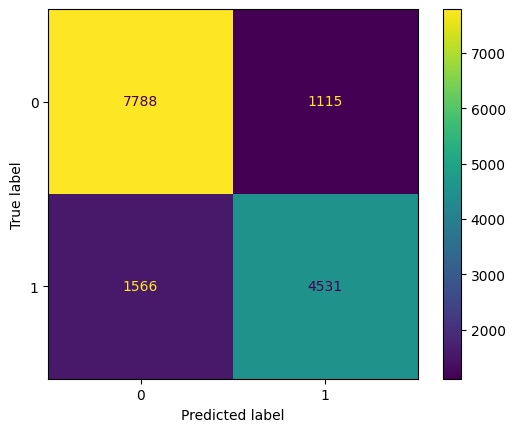

In [67]:
print('Test Score:',knn.score(x_test,y_test)*100)
print('Train Score:',knn.score(x_train,y_train)*100)
print('\n\nClassification Report:\n', classification_report(y_test, y_pred))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

# Naive Bayes (GaussianNB)

In [68]:
from sklearn.naive_bayes import GaussianNB

In [69]:
model = GaussianNB()
model.fit(x_train,y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [70]:
y_pred1 = model.predict(x_test)
y_pred1 

array([1, 0, 1, ..., 0, 1, 1], shape=(15000,))

In [71]:
model_acc = accuracy_score(y_test,y_pred1)*100
print('Accuracy Score -',model_acc)

Accuracy Score - 82.3


Test Score: 82.3
Train Score: 82.25714285714287


Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.88      0.86      8903
           1       0.81      0.73      0.77      6097

    accuracy                           0.82     15000
   macro avg       0.82      0.81      0.81     15000
weighted avg       0.82      0.82      0.82     15000


Confusion Matrix:
 [[7874 1029]
 [1626 4471]]


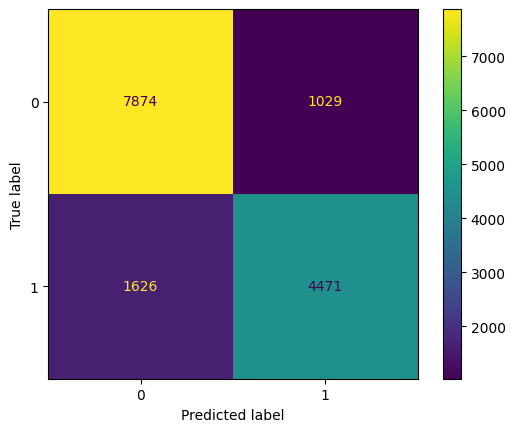

In [72]:
print('Test Score:',model.score(x_test,y_test)*100)
print('Train Score:',model.score(x_train,y_train)*100)
print('\n\nClassification Report:\n', classification_report(y_test, y_pred1))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred1))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred1))

# Logistic Regression

In [73]:
from sklearn.linear_model import LogisticRegression

In [74]:
log = LogisticRegression()
log.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [75]:
y_pred3=log.predict(x_test)
y_pred3

array([1, 1, 1, ..., 0, 1, 1], shape=(15000,))

In [76]:
log_acc = accuracy_score(y_test,y_pred3)*100
print('Accuracy Score -',log_acc)

Accuracy Score - 81.06666666666666


Test Score: 81.06666666666666
Train Score: 81.08


Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.86      0.84      8903
           1       0.78      0.74      0.76      6097

    accuracy                           0.81     15000
   macro avg       0.81      0.80      0.80     15000
weighted avg       0.81      0.81      0.81     15000


Confusion Matrix:
 [[7623 1280]
 [1560 4537]]


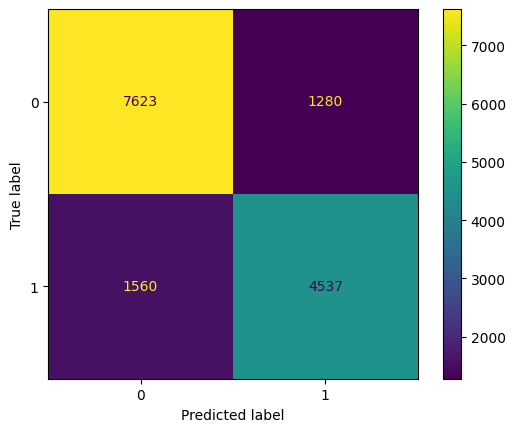

In [77]:
print('Test Score:',log.score(x_test,y_test)*100)
print('Train Score:',log.score(x_train,y_train)*100)
print('\n\nClassification Report:\n', classification_report(y_test, y_pred3))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred3))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred3))

# Decision Tree

In [78]:
from sklearn.tree import DecisionTreeClassifier

In [79]:
tree = DecisionTreeClassifier(max_depth=7)
tree.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [80]:
y_pred4 =tree.predict(x_test)
y_pred4

array([1, 1, 0, ..., 0, 0, 0], shape=(15000,))

In [81]:
tree_acc = accuracy_score(y_test,y_pred4)*100
print('Accuracy Score -',tree_acc)

Accuracy Score - 98.78666666666666


Test Score: 98.78666666666666
Train Score: 98.84571428571428


Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99      8903
           1       0.98      0.99      0.99      6097

    accuracy                           0.99     15000
   macro avg       0.99      0.99      0.99     15000
weighted avg       0.99      0.99      0.99     15000


Confusion Matrix:
 [[8763  140]
 [  42 6055]]


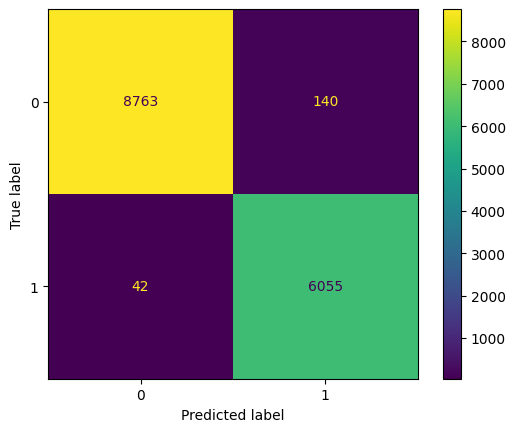

In [82]:
print('Test Score:',tree.score(x_test,y_test)*100)
print('Train Score:',tree.score(x_train,y_train)*100)
print('\n\nClassification Report:\n', classification_report(y_test, y_pred4))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred4))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred4))

# XG Boost

In [83]:
!pip install xgboost

In [84]:
from xgboost import XGBClassifier

In [85]:
xgboost=XGBClassifier(n_estimators=100 ,estimator =None,learning_rate =0.2,random_state =42)
xgboost.fit(x_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [86]:
y_pred5=xgboost.predict(x_test)
y_pred5

array([1, 1, 0, ..., 0, 1, 0], shape=(15000,))

In [87]:
xgboost_acc = accuracy_score(y_test,y_pred5)*100
print('Accuracy Score -',xgboost_acc)

Accuracy Score - 99.80666666666667


Test Score: 99.80666666666667
Train Score: 100.0


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      8903
           1       1.00      1.00      1.00      6097

    accuracy                           1.00     15000
   macro avg       1.00      1.00      1.00     15000
weighted avg       1.00      1.00      1.00     15000


Confusion Matrix:
 [[8891   12]
 [  17 6080]]


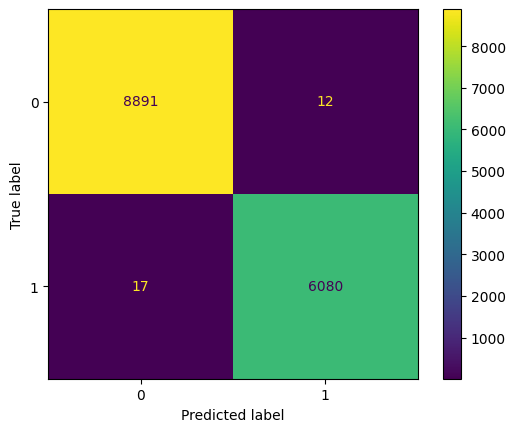

In [88]:
print('Test Score:',xgboost.score(x_test,y_test)*100)
print('Train Score:',xgboost.score(x_train,y_train)*100)
print('\n\nClassification Report:\n', classification_report(y_test, y_pred5))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred5))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred5))

# Ada Boost

In [89]:
from sklearn.ensemble import AdaBoostClassifier

In [90]:
ada=AdaBoostClassifier(n_estimators=100,learning_rate=0.5,random_state=42)
ada.fit(x_train,y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",100
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [91]:
y_pred6=ada.predict(x_test)
y_pred6

array([1, 1, 1, ..., 0, 1, 0], shape=(15000,))

In [92]:
ada_acc = accuracy_score(y_test,y_pred6)*100
print('Accuracy Score -',ada_acc)

Accuracy Score - 93.86666666666666


Test Score: 93.86666666666666
Train Score: 93.89428571428572


Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.98      0.95      8903
           1       0.97      0.88      0.92      6097

    accuracy                           0.94     15000
   macro avg       0.94      0.93      0.94     15000
weighted avg       0.94      0.94      0.94     15000


Confusion Matrix:
 [[8724  179]
 [ 741 5356]]


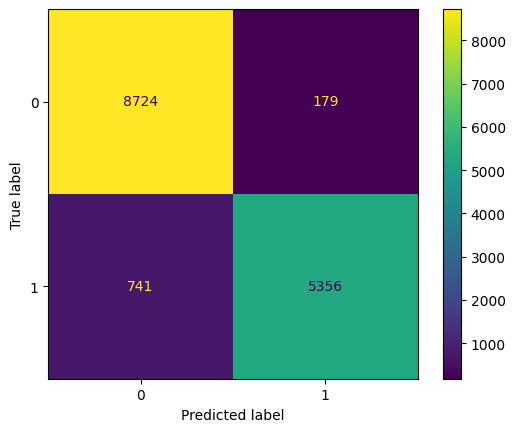

In [93]:
print('Test Score:',ada.score(x_test,y_test)*100)
print('Train Score:',ada.score(x_train,y_train)*100)
print('\n\nClassification Report:\n', classification_report(y_test, y_pred6))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred6))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred6))

# Gradient Boost

In [94]:
from sklearn.ensemble import GradientBoostingClassifier

In [95]:
gb=GradientBoostingClassifier(n_estimators=100,learning_rate=0.2,random_state=42)
gb.fit(x_train,y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.2
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [96]:
y_pred7=gb.predict(x_test)
y_pred7

array([1, 1, 0, ..., 0, 1, 0], shape=(15000,))

In [97]:
gb_acc = accuracy_score(y_test,y_pred7)*100
print('Accuracy Score -',gb_acc)

Accuracy Score - 100.0


Test Score: 100.0
Train Score: 99.99714285714286


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      8903
           1       1.00      1.00      1.00      6097

    accuracy                           1.00     15000
   macro avg       1.00      1.00      1.00     15000
weighted avg       1.00      1.00      1.00     15000


Confusion Matrix:
 [[8903    0]
 [   0 6097]]


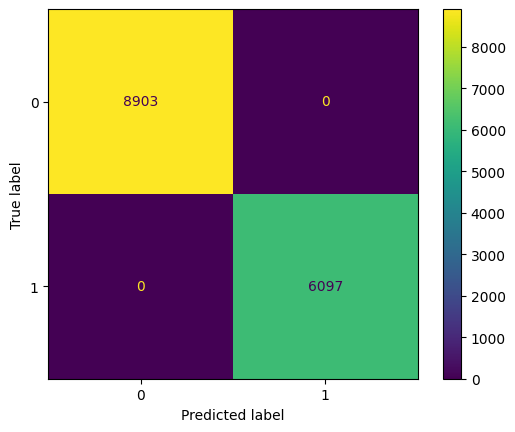

In [98]:
print('Test Score:',gb.score(x_test,y_test)*100)
print('Train Score:',gb.score(x_train,y_train)*100)
print('\n\nClassification Report:\n', classification_report(y_test, y_pred7))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred7))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred7))

# Random Forest

In [99]:
from sklearn.ensemble import RandomForestClassifier

In [100]:
rfc = RandomForestClassifier(n_estimators =100 ,random_state =42)
rfc.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [101]:
y_pred8 =rfc.predict(x_test)
y_pred8

array([1, 1, 1, ..., 0, 1, 0], shape=(15000,))

In [102]:
rfc_acc = accuracy_score(y_test,y_pred8)*100
print('Accuracy Score',rfc_acc)

Accuracy Score 99.5


Test Score: 99.5
Train Score: 100.0


Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00      8903
           1       0.99      1.00      0.99      6097

    accuracy                           0.99     15000
   macro avg       0.99      1.00      0.99     15000
weighted avg       1.00      0.99      1.00     15000


Confusion Matrix:
 [[8829   74]
 [   1 6096]]


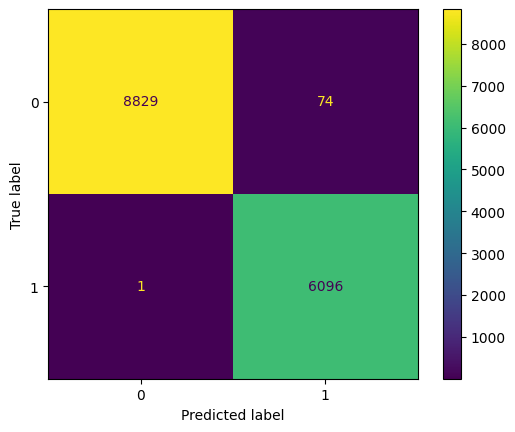

In [103]:
print('Test Score:',rfc.score(x_test,y_test)*100)
print('Train Score:',rfc.score(x_train,y_train)*100)
print('\n\nClassification Report:\n', classification_report(y_test, y_pred8))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred8))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred8))

# INITIAL ACCURACY

In [104]:
a=pd.DataFrame()
a['Model']=pd.Series(['KNeighborsClassifier','GaussianNB','LogisticRegression','DecisionTreeClassifier','XGBClassifier','AdaBoostClassifier','GradientBoostingClassifier','RandomForestClassifier'])
a['Initial Accuracy']=pd.Series([knn_acc,model_acc,log_acc,tree_acc,xgboost_acc,ada_acc,gb_acc,rfc_acc])
a.sort_values(by='Initial Accuracy', ascending=False).reset_index(drop=True)

,Model,Initial Accuracy
0,GradientBoostingClassifier,100.000000
1,XGBClassifier,99.806667
2,RandomForestClassifier,99.500000
3,DecisionTreeClassifier,98.786667
4,AdaBoostClassifier,93.866667
5,GaussianNB,82.300000
6,KNeighborsClassifier,82.126667
7,LogisticRegression,81.066667


In [105]:
new_data['Bankrupt'].value_counts()

Bankrupt
0    29339
1    20661
Name: count, dtype: int64

## Hyperparameter Tuning 

# K-Nearest Neighbors (KNN)

In [106]:
from sklearn.model_selection import GridSearchCV

In [107]:
knn=KNeighborsClassifier()    
par={'n_neighbors':[3,5,7,9],'weights':['uniform','distance']}
knn_t=GridSearchCV(knn,par,cv=5,scoring='accuracy')
knn_t.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;

In [108]:
print(knn_t.best_params_)
print(knn_t.best_score_) 

{'n_neighbors': 9, 'weights': 'distance'}
0.8427714285714286


In [111]:
knn2=KNeighborsClassifier(n_neighbors=3,weights='distance') 
knn2.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [112]:
y_pred0=knn2.predict(x_test)
y_pred0

array([1, 0, 1, ..., 0, 1, 0], shape=(15000,))

In [113]:
knn_acc2 = accuracy_score(y_test,y_pred0)*100
print('Accuracy Score',knn_acc2)

Accuracy Score 82.12


Test Score: 82.12
Train Score: 100.0


Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.87      0.85      8903
           1       0.80      0.74      0.77      6097

    accuracy                           0.82     15000
   macro avg       0.82      0.81      0.81     15000
weighted avg       0.82      0.82      0.82     15000


Confusion Matrix:
 [[7788 1115]
 [1567 4530]]


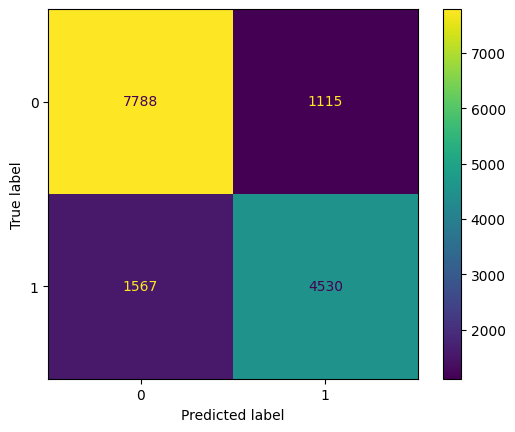

In [115]:
print('Test Score:',knn2.score(x_test,y_test)*100)
print('Train Score:',knn2.score(x_train,y_train)*100)
print('\n\nClassification Report:\n', classification_report(y_test, y_pred0))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred0))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred0))

# Naive Bayes (GaussianNB)

In [116]:
model2 = GaussianNB()
model2.fit(x_train,y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [117]:
y_pred02 = model2.predict(x_test)
y_pred02

array([1, 0, 1, ..., 0, 1, 1], shape=(15000,))

In [118]:
model_acc2 = accuracy_score(y_test,y_pred02)*100
print('Accuracy Score -',model_acc2)

Accuracy Score - 82.3


Test Score: 82.3
Train Score: 82.25714285714287


Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.88      0.86      8903
           1       0.81      0.73      0.77      6097

    accuracy                           0.82     15000
   macro avg       0.82      0.81      0.81     15000
weighted avg       0.82      0.82      0.82     15000


Confusion Matrix:
 [[7874 1029]
 [1626 4471]]


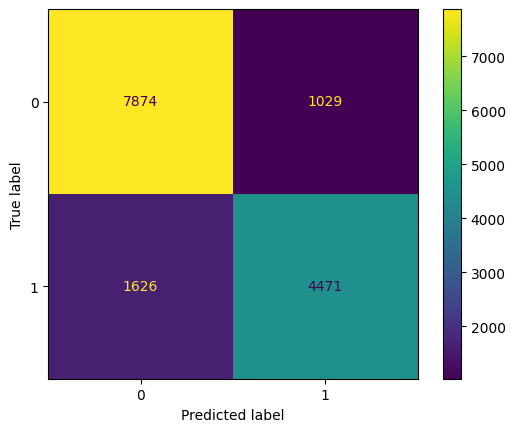

In [119]:
print('Test Score:',model2.score(x_test,y_test)*100)
print('Train Score:',model2.score(x_train,y_train)*100)
print('\n\nClassification Report:\n', classification_report(y_test, y_pred02))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred02))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred02))

# Logistic Regression

In [120]:
log=LogisticRegression()
par={'C':[0.01,0.1,0.5,1,10],'penalty':['l1','l2']}
log_t=GridSearchCV(log,par,cv=10,scoring='accuracy')
log_t.fit(x_train,y_train)
print(log_t.best_params_)
print(log_t.best_score_)

{'C': 0.01, 'penalty': 'l2'}
0.8112


In [121]:
log2=LogisticRegression(C=10, penalty='l2') 
log2.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",10
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` 

In [122]:
y_pred03=log2.predict(x_test)
y_pred03

array([1, 1, 1, ..., 0, 1, 1], shape=(15000,))

In [123]:
log_acc2 = accuracy_score(y_test,y_pred03)*100
print('Accuracy Score -',log_acc2)

Accuracy Score - 81.06666666666666


Test Score: 81.06666666666666
Train Score: 81.08


Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.86      0.84      8903
           1       0.78      0.74      0.76      6097

    accuracy                           0.81     15000
   macro avg       0.81      0.80      0.80     15000
weighted avg       0.81      0.81      0.81     15000


Confusion Matrix:
 [[7623 1280]
 [1560 4537]]


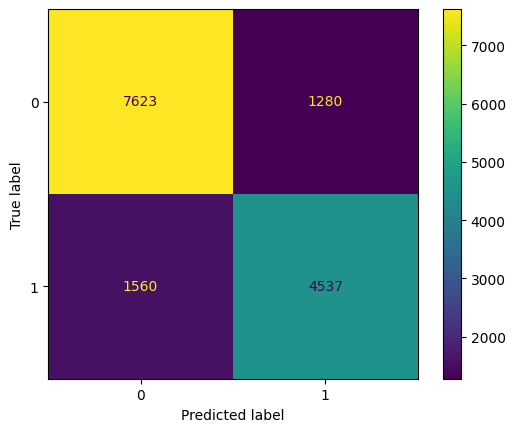

In [124]:
print('Test Score:',log2.score(x_test,y_test)*100)
print('Train Score:',log2.score(x_train,y_train)*100)
print('\n\nClassification Report:\n', classification_report(y_test, y_pred03))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred03))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred03))

# Decision Tree

In [125]:
tree = DecisionTreeClassifier()
par={'max_depth':[3,5,7,10,15,20],'min_samples_split':[2,5,10,20]}
tree_t=GridSearchCV(tree,par,cv=5,scoring='accuracy',n_jobs=-1)
tree_t.fit(x_train,y_train) 
print(tree_t.best_params_)
print(tree_t.best_score_)

{'max_depth': 10, 'min_samples_split': 20}
0.9990285714285714


In [126]:
tree2=DecisionTreeClassifier(max_depth=20,min_samples_split=2) 
tree2.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [127]:
y_pred=tree2.predict(x_test)
y_pred

array([1, 1, 0, ..., 0, 0, 0], shape=(15000,))

In [128]:
tree_acc2 = accuracy_score(y_test,y_pred)*100
print('Accuracy Score -',tree_acc2)

Accuracy Score - 99.88


Test Score: 99.88
Train Score: 100.0


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      8903
           1       1.00      1.00      1.00      6097

    accuracy                           1.00     15000
   macro avg       1.00      1.00      1.00     15000
weighted avg       1.00      1.00      1.00     15000


Confusion Matrix:
 [[8899    4]
 [  14 6083]]


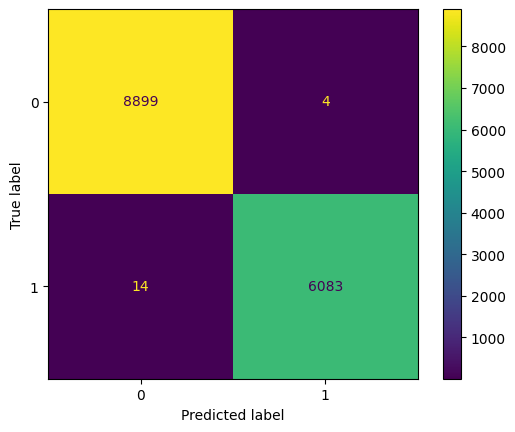

In [131]:
print('Test Score:',tree2.score(x_test,y_test)*100)
print('Train Score:',tree2.score(x_train,y_train)*100)
print('\n\nClassification Report:\n', classification_report(y_test, y_pred))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

# XG Boost

In [138]:
xgboost=XGBClassifier()
par={'max_depth': [3, 5, 7, 10],'learning_rate': [0.01, 0.05, 0.1, 0.3],'n_estimators': [100, 200, 300]}
xgboost_t=GridSearchCV(xgboost,par,cv=5,scoring='accuracy',n_jobs=-1)
xgboost_t.fit(x_train,y_train) 
print(xgboost_t.best_params_)
print(xgboost_t.best_score_)

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
0.9975714285714286


In [139]:
xgboost2=XGBClassifier(learning_rate=0.3,max_depth =7,n_estimators=300) 
xgboost2.fit(x_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [140]:
y_pred=xgboost2.predict(x_test)
y_pred

array([1, 1, 0, ..., 0, 1, 0], shape=(15000,))

In [141]:
xgboost_acc2 = accuracy_score(y_test,y_pred)*100
print('Accuracy Score -',xgboost_acc2)

Accuracy Score - 99.85333333333334


Test Score: 99.85333333333334
Train Score: 100.0


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      8903
           1       1.00      1.00      1.00      6097

    accuracy                           1.00     15000
   macro avg       1.00      1.00      1.00     15000
weighted avg       1.00      1.00      1.00     15000


Confusion Matrix:
 [[8895    8]
 [  14 6083]]


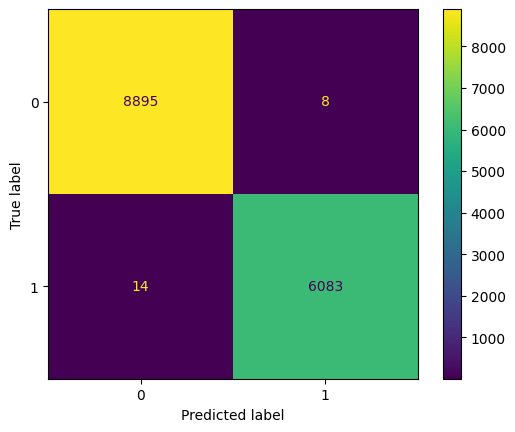

In [142]:
print('Test Score:',xgboost2.score(x_test,y_test)*100)
print('Train Score:',xgboost2.score(x_train,y_train)*100)
print('\n\nClassification Report:\n', classification_report(y_test, y_pred))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

# Ada Boost

In [143]:
ada=AdaBoostClassifier()
par={'n_estimators':[50, 100, 150, 200],'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0]}
ada_t=GridSearchCV(ada,par,cv=5,scoring='accuracy',n_jobs=-1)
ada_t.fit(x_train,y_train)
print(ada_t.best_params_)
print(ada_t.best_score_)

{'learning_rate': 1.0, 'n_estimators': 150}
0.9994000000000002


In [144]:
ada2=AdaBoostClassifier(learning_rate=0.5,n_estimators=150) 
ada2.fit(x_train,y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",150
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [145]:
y_pred=ada2.predict(x_test)
y_pred

array([1, 1, 1, ..., 0, 1, 0], shape=(15000,))

In [146]:
ada_acc2 = accuracy_score(y_test,y_pred)*100
print('Accuracy Score -',ada_acc2)

Accuracy Score - 96.8


Test Score: 96.8
Train Score: 96.89142857142858


Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.97      8903
           1       0.96      0.96      0.96      6097

    accuracy                           0.97     15000
   macro avg       0.97      0.97      0.97     15000
weighted avg       0.97      0.97      0.97     15000


Confusion Matrix:
 [[8691  212]
 [ 268 5829]]


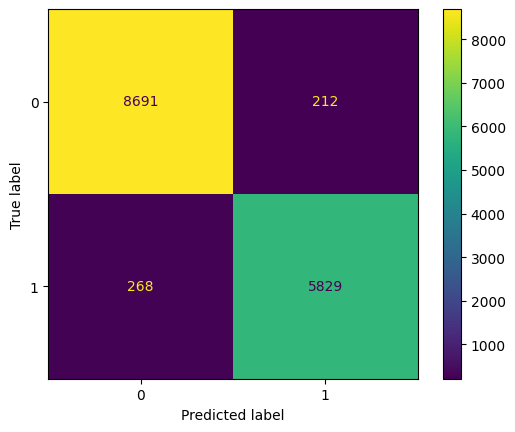

In [147]:
print('Test Score:',ada2.score(x_test,y_test)*100)
print('Train Score:',ada2.score(x_train,y_train)*100)
print('\n\nClassification Report:\n', classification_report(y_test, y_pred))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

# Gradient Boost

In [148]:
gb=GradientBoostingClassifier()
par={ 'n_estimators': [50, 100, 150, 200],'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0]}
gb_t=GridSearchCV(gb,par,cv=5,scoring='accuracy',n_jobs=-1)
gb_t.fit(x_train,y_train)
print(gb_t.best_params_)
print(gb_t.best_score_)

{'learning_rate': 0.1, 'n_estimators': 200}
0.9998857142857144


In [149]:
gb2=GradientBoostingClassifier(learning_rate=0.5,n_estimators=100) 
gb2.fit(x_train,y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.5
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [150]:
y_pred=gb2.predict(x_test)
y_pred

array([1, 1, 0, ..., 0, 1, 0], shape=(15000,))

In [151]:
gb_acc2 = accuracy_score(y_test,y_pred)*100
print('Accuracy Score -',gb_acc2)

Accuracy Score - 100.0


Test Score: 100.0
Train Score: 100.0


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      8903
           1       1.00      1.00      1.00      6097

    accuracy                           1.00     15000
   macro avg       1.00      1.00      1.00     15000
weighted avg       1.00      1.00      1.00     15000


Confusion Matrix:
 [[8903    0]
 [   0 6097]]


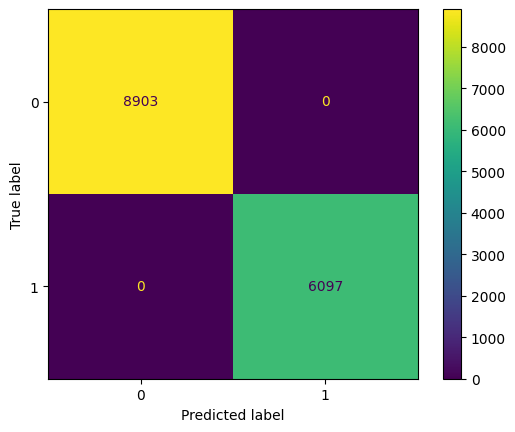

In [152]:
print('Test Score:',gb2.score(x_test,y_test)*100)
print('Train Score:',gb2.score(x_train,y_train)*100)
print('\n\nClassification Report:\n', classification_report(y_test, y_pred))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

# Random Forest Classifier

In [153]:
rf=RandomForestClassifier()
par={'n_estimators': [100, 200],'max_depth': [5, 10, 15]}
rf_t=GridSearchCV(rf,par,cv=5,scoring='accuracy',n_jobs=-1)
rf_t.fit(x_train,y_train)
print(rf_t.best_params_)
print(rf_t.best_score_)

{'max_depth': 15, 'n_estimators': 200}
0.9907999999999999


In [154]:
rf2=RandomForestClassifier(max_depth=15 ,n_estimators=200) 
rf2.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [155]:
y_pred=rf2.predict(x_test)
y_pred

array([1, 1, 0, ..., 0, 1, 0], shape=(15000,))

In [156]:
rf_acc2 = accuracy_score(y_test,y_pred)*100
print('Accuracy Score -',rf_acc2)

Accuracy Score - 99.26


Test Score: 99.26
Train Score: 100.0


Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99      8903
           1       0.98      1.00      0.99      6097

    accuracy                           0.99     15000
   macro avg       0.99      0.99      0.99     15000
weighted avg       0.99      0.99      0.99     15000


Confusion Matrix:
 [[8793  110]
 [   1 6096]]


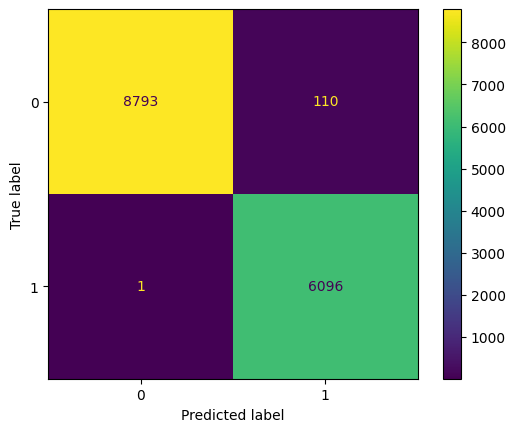

In [157]:
print('Test Score:',rf2.score(x_test,y_test)*100)
print('Train Score:',rf2.score(x_train,y_train)*100)
print('\n\nClassification Report:\n', classification_report(y_test, y_pred))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

# Accuracy after hyperparameter tuning

In [163]:
b=pd.DataFrame()
b['Model']=pd.Series(['KNeighborsClassifier','GaussianNB','LogisticRegression','DecisionTreeClassifier','XGBClassifier','AdaBoostClassifier','GradientBoostingClassifier','RandomForestClassifier'])
b['Initial Accuracy']=pd.Series([knn_acc,model_acc,log_acc,tree_acc,xgboost_acc,ada_acc,gb_acc,rfc_acc])
b['Accuracy after Hyperparameter Tuning']=pd.Series([knn_acc2,model_acc2,log_acc2,tree_acc2,xgboost_acc2,ada_acc2,gb_acc2,rf_acc2])
b.sort_values(by= ['Initial Accuracy','Accuracy after Hyperparameter Tuning'], ascending=False).reset_index(drop=True)

,Model,Initial Accuracy,Accuracy after Hyperparameter Tuning
0,GradientBoostingClassifier,100.000000,100.000000
1,XGBClassifier,99.806667,99.853333
2,RandomForestClassifier,99.500000,99.260000
3,DecisionTreeClassifier,98.786667,99.880000
4,AdaBoostClassifier,93.866667,96.800000
5,GaussianNB,82.300000,82.300000
6,KNeighborsClassifier,82.126667,82.120000
7,LogisticRegression,81.066667,81.066667


In [165]:
knn_train=knn2.score(x_train,y_train)
model_train=model2.score(x_train,y_train)
log_train=log2.score(x_train,y_train)
tree_train=tree2.score(x_train,y_train)
xgboost_train=xgboost2.score(x_train,y_train)
ada_train=ada2.score(x_train,y_train)
gb_train=gb2.score(x_train,y_train)
rf_train=rf2.score(x_train,y_train)

In [167]:
c=pd.DataFrame()
c['Model']=pd.Series(['KNeighborsClassifier','GaussianNB','LogisticRegression','DecisionTreeClassifier','XGBClassifier','AdaBoostClassifier','GradientBoostingClassifier','RandomForestClassifier'])
c['Test Accuracy']=pd.Series([knn_acc2,model_acc2,log_acc2,tree_acc2,xgboost_acc2,ada_acc2,gb_acc2,rf_acc2])
c['Train Accuracy']=pd.Series([knn_train,model_train,log_train,tree_train,xgboost_train,ada_train,gb_train,rf_train])
c.sort_values(by= ['Test Accuracy', 'Train Accuracy'], ascending=False).reset_index(drop=True)

,Model,Test Accuracy,Train Accuracy
0,GradientBoostingClassifier,100.000000,1.000000
1,DecisionTreeClassifier,99.880000,1.000000
2,XGBClassifier,99.853333,1.000000
3,RandomForestClassifier,99.260000,1.000000
4,AdaBoostClassifier,96.800000,0.968914
5,GaussianNB,82.300000,0.822571
6,KNeighborsClassifier,82.120000,1.000000
7,LogisticRegression,81.066667,0.810800


In [168]:
import joblib

In [171]:
joblib.dump(tree2,r'bankruptcy dataset.pkl')
joblib.dump(le,r'le.pkl')
joblib.dump(le1,r'le1.pkl')
joblib.dump(le2,r'le2.pkl')
joblib.dump(le3,r'le3.pkl')
joblib.dump(sd,r'ss.pkl')

['ss.pkl']